# OptiAbt Versuchsdaten .mat zu .csv

In [ ]:
# # Das hier ist ein Matlab Script!!!!

# % --- KONFIGURATION ---
# % Dein neuer lokaler Pfad
# input_folder = 'D:\mbc_nba\OptiAbt_Daten\Versuche';
# output_folder = fullfile(input_folder, 'CSV_Export');

# % Zielordner erstellen, falls nicht vorhanden
# if ~exist(output_folder, 'dir')
#     mkdir(output_folder);
# end

# fprintf('Starte Export aus: %s\n', input_folder);

# % --- SCHLEIFE ÜBER ALLE DATEIEN (1 bis 39) ---
# for i = 1:39
#     filename = sprintf('%d.mat', i);
#     full_path = fullfile(input_folder, filename);
    
#     if isfile(full_path)
#         fprintf('--------------------------------------\n');
#         fprintf('Bearbeite Datei: %s\n', filename);
        
#         try
#             % Lade den Inhalt der Datei
#             file_content = load(full_path);
#             var_names = fieldnames(file_content);
            
#             found_something = false;
            
#             % Wir gehen jede Variable in der Datei durch
#             for k = 1:length(var_names)
#                 current_var_name = var_names{k};
#                 data_object = file_content.(current_var_name);
                
#                 % Check 1: Ist es eine Tabelle (table)?
#                 if istable(data_object) || istimetable(data_object)
                    
#                     csv_name = sprintf('%d_%s.csv', i, current_var_name);
#                     out_path = fullfile(output_folder, csv_name);
                    
#                     % Speichern (mit Semikolon für Excel)
#                     writetable(data_object, out_path, 'Delimiter', ';');
                    
#                     fprintf('  -> [ERFOLG] Tabelle ''%s'' gespeichert als %s\n', current_var_name, csv_name);
#                     found_something = true;
                    
#                 % Check 2: Ist es vielleicht eine Matrix (falls keine Table da ist)?
#                 elseif isnumeric(data_object) && numel(data_object) > 10
#                      csv_name = sprintf('%d_%s_matrix.csv', i, current_var_name);
#                      out_path = fullfile(output_folder, csv_name);
                     
#                      writematrix(data_object, out_path, 'Delimiter', ';');
#                      fprintf('  -> [MATRIX] Array ''%s'' gespeichert als %s\n', current_var_name, csv_name);
#                      found_something = true;
#                 end
#             end
            
#             if ~found_something
#                 fprintf('  -> WARNUNG: Datei %d enthält keine erkennbaren Daten. Inhalt: %s\n', i, strjoin(var_names, ', '));
#             end
            
#         catch ME
#             fprintf('  -> FEHLER bei Datei %d: %s\n', i, ME.message);
#         end
        
#     else
#         % Datei existiert nicht -> überspringen
#     end
# end

# fprintf('--------------------------------------\n');
# fprintf('Fertig! Die CSV-Dateien liegen in:\n%s\n', output_folder);

# OptiAbt Versuchsdaten Display

NameError: name 't_start_val' is not defined

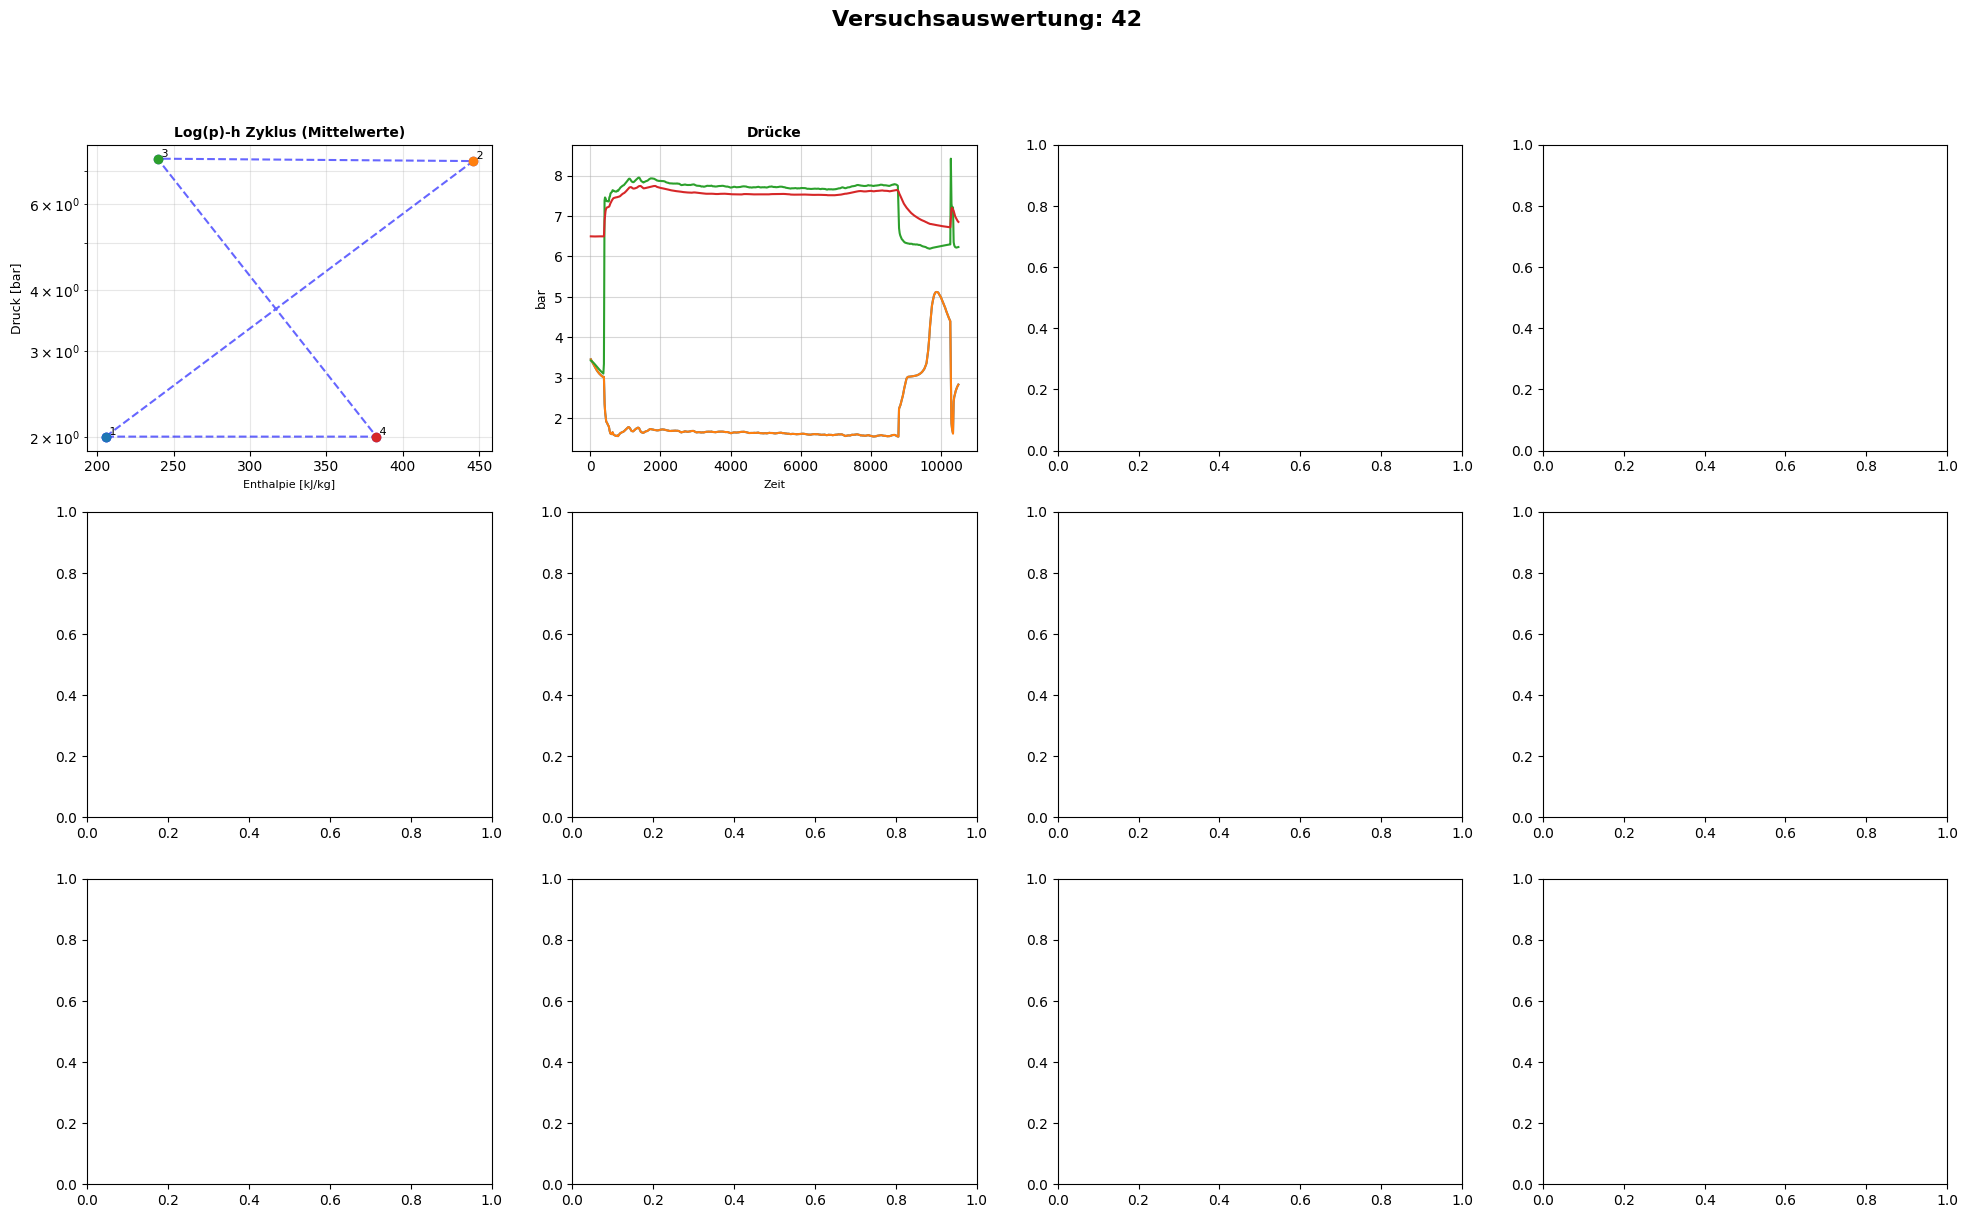

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


PATH = r"D:\mbc_nba\OptiAbt_Daten\Versuche\CSV_Export"
EXPERIMENT_ID =42

# Getting Experimental Data
file_data = os.path.join(PATH, f"{EXPERIMENT_ID}_data.csv")
file_kk = os.path.join(PATH, f"{EXPERIMENT_ID}_data_KK.csv")
df = pd.read_csv(file_data, sep=';', decimal='.', on_bad_lines='skip', low_memory=False)
df_kk = pd.read_csv(file_kk, sep=';', decimal='.', low_memory=False)


# =============================================================================================
# Extracting all necessary Data
# =============================================================================================
data = {}

# General
data["time"] = df['time']
col_modus = 'modus_val' if 'modus_val' in df.columns else 'modus'
data["modus"] = df[col_modus]
modus_1_idxs      = df.index[df[col_modus] == 1]

t_start_val = data["time"].iloc[modus_1_idxs[0]]
t_end_val   = data["time"].iloc[modus_1_idxs[-1]]

# Fan
data["VD_n1"] = df['VD_n1']
data["VD_n2"] = df['VD_n2']

# Air
col_rh = 'KK_rlFeuchteKK' if 'KK_rlFeuchteKK' in df_kk.columns else 'rlFeuchteKK'
data["rel_humidity"] = df_kk[col_rh]
data["T_air_in"] = df_kk['TempKK']
data["Delta_P_VD"] = df['Delta_P_VD']

# Refrigerant
data["m_dot_kg_refrigerant"] = df['MSS_rMassenstrom'] / 1000.0

# Evaporator in
data["evap_in_h"] = df['VD_h_in_korr']
data["evap_in_p"] = df['VD_p_in']

# Evaporator out
data["evap_out_h"] = df['VD_h_out']
data["evap_out_p"] = df['VD_p_out']

# Condenser in
data["cond_in_h"] = df['VF_h_in']
data["cond_in_p"] = df['VF_p_in']

# Condenser out
data["cond_out_h"] = df['VF_h_out']
data["cond_out_p"] = df['VF_p_out']

# Heat and Power
data['P_fan']       = df['KP_Power'] / 1000.0
data['Q_evap_calc'] = data["m_dot_kg_refrigerant"] * (data["evap_out_h"] - data["evap_in_h"])
data['Q_cond_calc'] = data["m_dot_kg_refrigerant"] * (data["cond_in_h"]  - data["cond_out_h"])
data['COP']         = data['Q_cond_calc'] / data['P_fan']

# Frost Mass
col_mass = 'WAAGEN_Waage1_Masse_smooth' if 'WAAGEN_Waage1_Masse_smooth' in df.columns else 'WAAGEN_Waage2_Masse'
mass_raw = df[col_mass]
mass_start = mass_raw.loc[modus_1_start_idx]
data["mass_frost"] = mass_raw - mass_start 



# =============================================================================================
# PLOTTING STRATEGY
# =============================================================================================

# Canvas vorbereiten: 3 Zeilen, 4 Spalten (16:9 Aspect Ratio)
fig, axes = plt.subplots(3, 4, figsize=(24, 13.5))
fig.suptitle(f"Versuchsauswertung: {EXPERIMENT_ID}", fontsize=16, fontweight='bold')

# Flatten axes array for easy indexing (0 to 11)
ax = axes.flatten()

time_axis = data['time']

# Helper Funktion für Zeit-Plots
def plot_time_series(ax_idx, keys, title, ylabel, combine_legend=True):
    current_ax = ax[ax_idx]
    
    # Keys kann ein einzelner String oder eine Liste sein
    if isinstance(keys, str):
        keys = [keys]
        
    for k in keys:
        if k in data:
            current_ax.plot(time_axis, data[k], label=k, linewidth=1.5)
    
    current_ax.set_title(title, fontsize=10, fontweight='bold')
    current_ax.set_ylabel(ylabel, fontsize=9)
    current_ax.set_xlabel('Zeit', fontsize=8)
    current_ax.grid(True, alpha=0.5)
    
    # Vertikale Linien für Modus 1
    if t_start_val is not None:
        current_ax.axvline(x=t_start_val, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    if t_end_val is not None:
        current_ax.axvline(x=t_end_val, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
        
    current_ax.legend(fontsize=8, loc='best')

# --- PLOT 1: Log(p)-h Diagramm (Spezialfall, keine Zeitachse) ---
def plot_logph_cycle(ax_idx):
    current_ax = ax[ax_idx]
    current_ax.set_title("Log(p)-h Zyklus (Mittelwerte)", fontsize=10, fontweight='bold')
    
    # Reihenfolge Zyklus
    cycle_points = [
        ('1: Evap Out (VD in)', data['evap_in_h'],  data['evap_in_p']),  # Benennung angepasst auf Logik
        ('2: Comp Out (VF in)', data['cond_in_h'],  data['cond_in_p']),
        ('3: Cond Out (VF out)', data['cond_out_h'], data['cond_out_p']),
        ('4: Evap In (VD out)',  data['evap_out_h'], data['evap_out_p'])  # Checke Benennung in deinen Daten
    ]
    
    h_means = []
    p_means = []
    
    for name, h_s, p_s in cycle_points:
        h_m = np.mean(h_s)
        p_m = np.mean(p_s)
        h_means.append(h_m)
        p_means.append(p_m)
        current_ax.scatter(h_m, p_m, zorder=5)
        current_ax.text(h_m, p_m, f" {name.split(':')[0]}", fontsize=8, verticalalignment='bottom')

    # Linie schließen
    current_ax.plot(h_means + [h_means[0]], p_means + [p_means[0]], 'b--', marker='o', alpha=0.6)
    
    current_ax.set_yscale('log')
    current_ax.set_xlabel('Enthalpie [kJ/kg]', fontsize=8)
    current_ax.set_ylabel('Druck [bar]', fontsize=9)
    current_ax.grid(True, which="both", alpha=0.3)

# =============================================================================================
# AUSFÜHRUNG DER PLOTS
# =============================================================================================

# Zeile 1: Thermodynamik Hauptdaten
plot_logph_cycle(0)
plot_time_series(1, ['evap_in_p', 'evap_out_p', 'cond_in_p', 'cond_out_p'], "Drücke", "bar")
plot_time_series(2, ['evap_in_h', 'evap_out_h', 'cond_in_h', 'cond_out_h'], "Enthalpien", "kJ/kg")
plot_time_series(3, ['P_fan', 'Q_evap_calc', 'Q_cond_calc'], "Leistungen / Wärmeströme", "kW")

# Zeile 2: Komponenten & Luft
plot_time_series(4, ['VD_n1', 'VD_n2'], "Lüfterdrehzahlen", "rpm")
plot_time_series(5, 'Delta_P_VD', "Druckverlust Verdampfer (Luft)", "Pa")
plot_time_series(6, 'T_air_in', "Lufteintrittstemperatur", "°C")
plot_time_series(7, 'rel_humidity', "Relative Feuchte", "%")

# Zeile 3: Massen & Effizienz & Status
plot_time_series(8, 'm_dot_kg_refrigerant', "Kältemittelmassenstrom", "kg/s")
plot_time_series(9, 'mass_frost', "Reifmasse (akkumuliert)", "g (oder kg)") # Einheit prüfen
plot_time_series(10, 'COP', "COP (Coefficient of Performance)", "-")
plot_time_series(11, 'modus', "Betriebsmodus", "Status")

# Layout straffen
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Platz für Main Title lassen

# Anzeigen
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import traceback  # WICHTIG für Fehlersuche

# ==========================================
# 1. KONFIGURATION
# ==========================================
PATH = r"D:\mbc_nba\OptiAbt_Daten\Versuche\CSV_Export"

EXPERIMENT_IDS = np.arange(40,41)

# Ordner für die Grafiken
OUTPUT_FOLDER = os.path.join(PATH, 'graphics')
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

# ==========================================
# HAUPTSCHLEIFE
# ==========================================
for VERSUCH_NR in EXPERIMENT_IDS:
    print(f"--- Verarbeite Versuch {VERSUCH_NR} ---")

    # Dateipfade (f-strings garantieren, dass es Strings sind)
    file_data = os.path.join(PATH, f"{VERSUCH_NR}_data.csv")
    file_kk = os.path.join(PATH, f"{VERSUCH_NR}_data_KK.csv")

    if not os.path.exists(file_data):
        print(f"Warnung: Datei {file_data} nicht gefunden. Überspringe.")
        continue

    try:
        # ==========================================
        # 2. DATEN LADEN & BEREINIGEN
        # ==========================================
        # low_memory=False hilft bei Mixed Types Warnungen
        df = pd.read_csv(file_data, sep=';', decimal='.', on_bad_lines='skip', low_memory=False)
        
        if os.path.exists(file_kk):
            df_kk = pd.read_csv(file_kk, sep=';', decimal='.', low_memory=False)
        else:
            df_kk = pd.DataFrame()
            print(f"Info: Keine KK-Daten für Versuch {VERSUCH_NR}")

        # --- WICHTIG: Datenbereinigung ---
        # Wir erzwingen numerische Werte. Fehlerhafte Zellen (Strings) werden zu NaN
        numeric_cols = ['MSS_rMassenstrom', 'VD_h_out', 'VD_h_in_korr', 'VF_h_in', 'VF_h_out', 'KP_Power', 'VD_n1', 'VD_n2']
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')

        # Berechnungen
        m_dot_kg = df['MSS_rMassenstrom'] / 1000.0
        df['Q_V_calc'] = m_dot_kg * (df['VD_h_out'] - df['VD_h_in_korr'])
        df['Q_K_calc'] = m_dot_kg * (df['VF_h_in'] - df['VF_h_out'])
        df['P_Verdichter'] = df['KP_Power'] / 1000.0
        df['COP'] = df['Q_K_calc'] / df['P_Verdichter']

        # ==========================================
        # 3. PLOTTING
        # ==========================================
        t = pd.to_numeric(df['time'], errors='coerce') # Sicherstellen, dass Zeit numerisch ist
        t_kk = pd.to_numeric(df_kk['time'], errors='coerce') if not df_kk.empty else []

        fig, axs = plt.subplots(5, 2, figsize=(16, 24), sharex=True)
        fig.suptitle(f'Auswertung Versuch {VERSUCH_NR}', fontsize=16)

        # [0,0] Drehzahl
        ax = axs[0, 0]
        ax.plot(t, df['VD_n1'], color='black', label='VD_n1')
        ax.plot(t, df['VD_n2'], color='gray', linestyle='--', label='VD_n2')
        ax.set_title('Ventilator Drehzahl')
        ax.grid(True); ax.legend()

        # [0,1] KK Luft
        ax = axs[0, 1]
        ax2 = ax.twinx()
        # Logik-Fix: Prüfe in df_kk, nutze in df_kk
        col_rf = 'KK_rlFeuchteKK' if 'KK_rlFeuchteKK' in df_kk.columns else 'rlFeuchteKK'
        
        # Sicherstellen, dass Spalten numerisch sind
        temp_kk = pd.to_numeric(df_kk['TempKK'], errors='coerce')
        rf_kk = pd.to_numeric(df_kk[col_rf], errors='coerce')
        
        l1 = ax.plot(t_kk, temp_kk, color='red', label='Temp KK')
        l2 = ax2.plot(t_kk, rf_kk, color='blue', label='r.F. KK')
        
        lns = l1 + l2
        labs = [l.get_label() for l in lns]
        ax.legend(lns, labs, loc='upper right')
        
        ax.set_title('Klimakammer Luft')
        ax.grid(True)

        # [1,0] Massenstrom
        axs[1, 0].plot(t, df['MSS_rMassenstrom'], color='green')
        axs[1, 0].set_title('Massenstrom KM')
        axs[1, 0].grid(True)

        # [1,1] Druckverlust Luft
        axs[1, 1].plot(t, df['Delta_P_VD'], color='purple')
        axs[1, 1].set_title('Druckverlust Luftseite')
        axs[1, 1].grid(True)

        # [2,0] Druck Verdampfer
        axs[2, 0].plot(t, df['VD_p_in'], label='p_in', color='tab:blue')
        axs[2, 0].set_title('Drücke Verdampfer'); axs[2, 0].legend(); axs[2, 0].grid(True)

        # [2,1] Enthalpien
        axs[2, 1].plot(t, df['VD_h_in_korr'], label='h_in_korr', color='tab:orange')
        axs[2, 1].plot(t, df['VD_h_out'], label='h_out', color='tab:red')
        axs[2, 1].set_title('Enthalpien'); axs[2, 1].legend(); axs[2, 1].grid(True)

        # [3,0] Leistungen
        axs[3, 0].plot(t, df['Q_V_calc'], color='magenta', label='Q_V')
        axs[3, 0].plot(t, df['Q_K_calc'], color='orange', label='Q_K')
        axs[3, 0].plot(t, df['P_Verdichter'], color='black', label='P_el')
        axs[3, 0].set_title('Leistungen'); axs[3, 0].legend(); axs[3, 0].grid(True)

        # [3,1] COP
        axs[3, 1].plot(t, df['COP'], color='darkblue')
        axs[3, 1].set_title('COP'); axs[3, 1].set_ylim(0, 8); axs[3, 1].grid(True)

        # [4,0] Modus
        col_modus = 'modus_val' if 'modus_val' in df.columns else 'modus' # Fix: Prüfe in df
        if col_modus in df.columns:
             axs[4, 0].plot(t, df[col_modus], color='brown', drawstyle='steps-post')
        axs[4, 0].set_title('Betriebsmodus'); axs[4, 0].grid(True)

        # [4,1] Reifmasse
        # Logik-Fix: Sicherstellen, dass wir nicht auf leere Daten zugreifen
        if col_modus in df.columns:
            idx_m1 = df.index[df[col_modus] == 1]
            if not idx_m1.empty:
                col_masse = 'WAAGEN_Waage1_Masse_smooth' if 'WAAGEN_Waage1_Masse_smooth' in df.columns else 'WAAGEN_Waage2_Masse'
                if col_masse in df.columns:
                    m_raw = pd.to_numeric(df.loc[idx_m1, col_masse], errors='coerce')
                    t_slice = t.loc[idx_m1]
                    m_start_val = m_raw.iloc[0]
                    axs[4, 1].plot(t_slice, m_raw - m_start_val, color='teal')
                    axs[4, 1].set_title(f'Reifmasse (Total: {m_raw.iloc[-1] - m_start_val:.3f} kg)')
        
        axs[4, 1].set_ylabel('Reifmasse [kg]')
        axs[4, 1].grid(True)

        plt.tight_layout()

        # ==========================================
        # SPEICHERN
        # ==========================================

        if EXPERIMENT_IDS.size > 1:
            save_filename = f"{VERSUCH_NR}_image.png"
            save_path = os.path.join(OUTPUT_FOLDER, save_filename)
            
            plt.savefig(save_path)
            plt.close(fig)
            print(f"-> Gespeichert: {save_filename}")
        else:
            plt.show()
            plt.close('all')

    except Exception:
        # HIER WIRD DER WAHRE FEHLER AUSGEGEBEN
        print(f"!!! KRITISCHER FEHLER bei Versuch {VERSUCH_NR} !!!")
        traceback.print_exc() # Zeigt die genaue Zeile und den Grund
        plt.close('all')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. DEINE EINGABEN ---
n_input = 1100   # Deine gemessene Drehzahl
p_input = 20     # Dein gemessener Druck
file_path = r"D:\mbc_nba\OptiAbt_Daten\Ventilatorkennlinie_Daten.csv"

# --- 2. DATEN LADEN ---
# Einheiten-Zeile überspringen (skiprows=[1]), encoding fallback falls nötig
df = pd.read_csv(file_path, sep=';', decimal='.', skiprows=[1], encoding='latin1')

# --- 3. BERECHNUNG (Curve Fitting / Ausgleichskurve) ---
# Ventilatorgesetze anwenden (Daten auf n_input normieren)
q_scaled = df['qV'] * (n_input / df['n'])
p_scaled = df['p_fs'] * (n_input / df['n'])**2

# Anstatt Punkte zu verbinden, fitten wir ein Polynom 2. Grades (Parabel)
# Funktion: p(q) = a*q^2 + b*q + c
coefficients = np.polyfit(q_scaled, p_scaled, 2)
p_func = np.poly1d(coefficients)

# --- Den gesuchten Volumenstrom berechnen ---
# Wir suchen q, wo p = p_input ist. Das heißt: Lösen der quadratischen Gleichung.
# p_func(q) - p_input = 0
roots = (p_func - p_input).roots

# Wir nehmen nur die sinnvolle Lösung (reell, positiv und im Bereich der Daten)
valid_roots = [r for r in roots if np.isreal(r) and r > 0]

if not valid_roots:
    q_ergebnis = 0
    print("Warnung: Kein Schnittpunkt gefunden (Druck zu hoch?)")
else:
    # Wir nehmen die Lösung, die am nächsten am Mittelwert deiner Daten liegt
    # (falls es theoretisch zwei Schnittpunkte gäbe)
    q_ergebnis = np.real(valid_roots[np.argmin(np.abs(np.array(valid_roots) - np.mean(q_scaled)))])
    print(f"Berechneter Volumenstrom (geglättet): {q_ergebnis:.2f} m³/h")

# --- 4. PLOTTEN ---
plt.figure(figsize=(11, 7))

# A) Originale Messdaten (Hintergrund)
sc = plt.scatter(df['qV'], df['p_fs'], c=df['n'], cmap='viridis', s=80, alpha=0.6, label='Original Messdaten')
cbar = plt.colorbar(sc)
cbar.set_label('Drehzahl $n$ [U/min]', fontsize=12)

# B) Die berechnete "Smooth"-Kurve für 1100 U/min
# Wir erzeugen uns schöne x-Werte für eine glatte Linie
q_smooth = np.linspace(0, q_scaled.max() * 1.1, 200)
p_smooth = p_func(q_smooth)

plt.plot(q_smooth, p_smooth, color='gray', linestyle='--', linewidth=2, label=f'Trendlinie bei {n_input} U/min')

# C) Deinen Punkt einzeichnen
plt.scatter(q_ergebnis, p_input, color='red', marker='X', s=200, label='Dein Betriebspunkt', zorder=5, edgecolor='white')

# D) Optional: Die projizierte Punktwolke (damit man sieht, wie gut der Fit ist)
plt.scatter(q_scaled, p_scaled, color='black', marker='.', alpha=0.5, label='Projizierte Rohdaten')

# Beschriftung und Layout
plt.title(f"Ventilatorkennlinie (Fit-Ergebnis: $q_V$ = {q_ergebnis:.1f} $m^3/h$)", fontsize=14)
plt.xlabel("Volumenstrom $q_V$ [$m^3/h$]", fontsize=12)
plt.ylabel("Statischer Druck $p_{fs}$ [$Pa$]", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')
plt.ylim(bottom=0)
plt.xlim(left=700)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import math

# ==========================================
# 1. KONFIGURATION
# ==========================================
PATH = r"D:\mbc_nba\OptiAbt_Daten\Versuche\CSV_Export"
VERSUCH_NR = 40
file_data = os.path.join(PATH, f"{VERSUCH_NR}_data.csv")

# ==========================================
# 2. LOAD DATA
# ==========================================
print(f"Loading {file_data}...")
df = pd.read_csv(file_data, sep=';', decimal='.', on_bad_lines='skip', low_memory=False)

# ==========================================
# 3. PLOTTING SETUP
# ==========================================
cols = df.columns
num_plots = len(cols)

# Define grid size (e.g., 3 columns wide)
ncols = 3
nrows = math.ceil(num_plots / ncols)

# Create the figure. Adjust figsize height based on number of rows to prevent squashing
# 5 units height per row is usually readable
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows), constrained_layout=True)

# Flatten axes to make it easy to loop through (1D array instead of 2D)
# If there is only 1 plot, axes is not a list, so we wrap it
if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()

print("Generating plots...")

# ==========================================
# 4. PLOTTING LOOP
# ==========================================
for i, col_name in enumerate(cols):
    ax = axes[i]
    ax.set_title(col_name, fontsize=10, fontweight='bold')
    
    try:
        # DATA PREPARATION
        # We attempt to convert to numeric, coercing errors to NaN.
        # This prevents string columns from crashing the plot immediately
        # allowing us to check if there is valid data.
        series_data = pd.to_numeric(df[col_name], errors='coerce')
        
        # Check if column is entirely empty or NaN after conversion
        if series_data.isna().all():
            raise ValueError("No numeric data found (Strings or NaNs)")
            
        # PLOT
        # Plotting against index (just by itself)
        ax.plot(series_data.index, series_data.values)
        ax.grid(True, linestyle='--', alpha=0.6)
        
    except Exception as e:
        # ERROR HANDLING
        # Clear specific axis styling to make the error stand out
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        ax.grid(False)
        
        # Write the error message in the center of the subplot
        error_msg = f"COULD NOT PLOT:\n{str(e)}"
        ax.text(0.5, 0.5, error_msg, 
                horizontalalignment='center', 
                verticalalignment='center', 
                transform=ax.transAxes, 
                color='red', fontsize=9, wrap=True)

# ==========================================
# 5. CLEANUP
# ==========================================
# Hide any empty subplots at the end (if plots don't fill the last row completely)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f"Data Overview: {VERSUCH_NR}_data.csv", fontsize=16)
plt.show()

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

# ================= 1. SETUP =================
INPUT_PATH  = r"D:\mbc_nba\OptiAbt_Daten\Versuche\CSV_Export"
OUTPUT_PATH = os.path.join(INPUT_PATH, "graphics")
FLUID       = 'R134a'
START_NR    = 40
END_NR      = 67

os.makedirs(OUTPUT_PATH, exist_ok=True)

# ================= 2. CALCULATE BACKGROUND (SATURATION LINES) =================
print("Calculating saturation curves...")
try:
    T_crit  = PropsSI('Tcrit', FLUID)
    T_vec_K = np.linspace(213.15, T_crit - 0.0001, 200) # -60°C to Critical Point
    
    # Calculate Enthalpy for liquid (Q=0) and vapor (Q=1)
    h_liq   = PropsSI('H', 'T', T_vec_K, 'Q', 0, FLUID) / 1000.0
    h_vap   = PropsSI('H', 'T', T_vec_K, 'Q', 1, FLUID) / 1000.0
    T_vec_C = T_vec_K - 273.15
    print("Done.\n")
except Exception as e:
    print(f"CoolProp Error: {e}")
    exit()

# ================= 3. PROCESS LOOP =================
for versuch_nr in range(START_NR, END_NR + 1):
    file_path = os.path.join(INPUT_PATH, f"{versuch_nr}_data.csv")

    if not os.path.exists(file_path):
        continue

    print(f"--- Processing Experiment {versuch_nr} ---")

    try:
        # --- Load Data ---
        df = pd.read_csv(file_path, sep=';', decimal='.', on_bad_lines='skip', low_memory=False)
        df_subset = df[df.get("modus_val") == 1]

        if df_subset.empty:
            print("No valid data (modus_val != 1).")
            continue

        # Extract middle row for representative point
        row = df_subset.iloc[len(df_subset) // 2].copy()

        # --- Extract Coordinates (Enthalpy h, Temperature T) ---
        # 1. Condenser (Verflüssiger) In/Out
        pt_VF_in  = (row.get("VF_h_in"), row.get("VF_T_in"))
        pt_VF_out = (row.get("VF_h_out"), row.get("VF_T_out"))

        # 2. Evaporator (Verdampfer) In/Out
        # Now get the actual value to use for calculation
        h_val_final = pd.to_numeric(row.get("VD_h_in_korr"), errors='coerce')
        p_val_final = pd.to_numeric(row.get("VD_p_in"), errors='coerce')

        # Calculate T_in only if both P and H are valid numbers
        if pd.notna(p_val_final) and pd.notna(h_val_final) and h_val_final > 0:
            try:
                T_calc = PropsSI('T', 'P', p_val_final * 1e5, 'H', h_val_final * 1000, FLUID)
                val_VD_T_in = T_calc - 273.15
            except Exception:
                val_VD_T_in = np.nan
        else:
            val_VD_T_in = np.nan
        
        pt_VD_in  = (h_val_final, val_VD_T_in)
        pt_VD_out = (row.get("VD_h_out"), row.get("VD_T_out"))

        # Check for completeness
        points_list = [pt_VF_in, pt_VF_out, pt_VD_in, pt_VD_out]
        if any(pd.isna(p[0]) or pd.isna(p[1]) for p in points_list):
            print("Warning: Missing data points. Plotting available data.")

        # ================= 4. PLOTTING =================
        plt.figure(figsize=(10, 7))

        # A) Draw Background
        plt.plot(h_liq, T_vec_C, color='gray', linewidth=1.0, label='Siedelinie')
        plt.plot(h_vap, T_vec_C, color='gray', linewidth=1.0, label='Taulinie')

        # B) Draw Condenser Process (Isobaric)
        if pd.notna(pt_VF_in[0]) and pd.notna(pt_VF_out[0]):
            try:
                # Attempt to plot curved isobar
                h_range = np.linspace(pt_VF_in[0], pt_VF_out[0], 50)
                p_pa = row.get("VF_p_in") * 1e5
                T_range = PropsSI('T', 'P', p_pa, 'H', h_range * 1000, FLUID) - 273.15
                plt.plot(h_range, T_range, 'k:', linewidth=2, label='Isobare')
            except:
                # Fallback to straight line
                plt.plot([pt_VF_in[0], pt_VF_out[0]], [pt_VF_in[1], pt_VF_out[1]], 'k-', linewidth=2)

        # C) Draw Expansion (Straight Line)
        if pd.notna(pt_VF_out[0]) and pd.notna(pt_VD_in[0]):
            plt.plot([pt_VF_out[0], pt_VD_in[0]], [pt_VF_out[1], pt_VD_in[1]], 'k-', linewidth=2)

        # D) Draw Evaporator Process (Isobaric)
        if pd.notna(pt_VD_in[0]) and pd.notna(pt_VD_out[0]):
            try:
                # Attempt to plot curved isobar
                h_range = np.linspace(pt_VD_in[0], pt_VD_out[0], 50)
                p_pa = row.get("VD_p_in") * 1e5
                T_range = PropsSI('T', 'P', p_pa, 'H', h_range * 1000, FLUID) - 273.15
                plt.plot(h_range, T_range, 'k:', linewidth=2)
            except:
                # Fallback to straight line
                plt.plot([pt_VD_in[0], pt_VD_out[0]], [pt_VD_in[1], pt_VD_out[1]], 'k-', linewidth=2)

        # E) Draw Suction Line (Straight Line)
        if pd.notna(pt_VD_out[0]) and pd.notna(pt_VF_in[0]):
            plt.plot([pt_VD_out[0], pt_VF_in[0]], [pt_VD_out[1], pt_VF_in[1]], 'k-', linewidth=2)

        # F) Draw Markers
        # Only plot points that exist
        if pd.notna(pt_VF_in[0]):
            plt.scatter([pt_VF_in[0], pt_VF_out[0]], [pt_VF_in[1], pt_VF_out[1]], 
                        label="Kondensator (VF)", marker="v", s=100, edgecolors='black', zorder=5)
            
        if pd.notna(pt_VD_in[0]):
            plt.scatter([pt_VD_in[0], pt_VD_out[0]], [pt_VD_in[1], pt_VD_out[1]], 
                        label="Verdampfer (VD)", marker="^", s=100, edgecolors='black', zorder=5)

        # ================= 5. STYLING & SAVING =================
        plt.title(f"T-h Diagramm {FLUID} (Versuch {versuch_nr})")
        plt.xlabel("Enthalpie $h$ [kJ/kg]")
        plt.ylabel("Temperatur $T$ [°C]")
        plt.xlim(150, 500)
        plt.ylim(-30, 110)
        plt.grid(True, linestyle='--', alpha=0.6)

        # Clean Legend (remove duplicates)
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys(), loc='upper left', shadow=True)

        plt.tight_layout()
        
        save_name = os.path.join(OUTPUT_PATH, f"Versuch_{versuch_nr}_Th_Diagramm.png")
        plt.savefig(save_name, dpi=300)
        plt.close()
        
        print(f"-> Saved: {save_name}")

    except Exception as e:
        print(f"Error in Versuch {versuch_nr}: {e}")
        plt.close()

print("\nAll tasks completed.")

In [ ]:
plt.figure()
plt.plot(df["VD_T_in"])
plt.show()

plt.figure()
plt.plot(df["VD_p_in"])
plt.show()

In [ ]:
# VD_h_in, VD_h_out
# VD_isenthalp_h_in
# VD_h_in_korr
# EV_in_h_in, EV_rev_in_h_in



plt.figure()
# plt.plot(df["VD_isenthalp_h_in"], label="VD_isenthalp_h_in")
# plt.plot(df["VD_h_in"], label="VD_h_in")
plt.plot(df["VD_h_in_korr"], label="VD_h_in_korr")
# plt.plot(df["EV_in_h_in"], label="EV_in_h_in")  
# plt.plot(df["EV_rev_in_h_in"], label="EV_rev_in_h_in")


plt.plot(df["VD_h_out"], label="VD_h_out")

plt.legend()
plt.figure()